# COSDUO - Stage 1 Final v3
**한국인 얼굴 이미지 기반 스킨케어 루틴 추천 시스템**

담당: 최여정

### 전체 순서
1. 환경 설정
2. 경로 설정
3. DenseNet121 정의 및 로드
4. **[Step 1]** skin 858명 Y값 완성 (Acne 추론 + 캐글 범위 맞추기)
5. **[Step 2]** skin 858명으로만 모델 3개 학습 및 비교
6. **[Step 3]** 최고 성능 모델로 disease 나머지 4개 추론
7. **[Step 4]** 2658명 완성 후 최종 모델 재학습
8. **[Step 5]** Dryness 멀티모달 모델 학습 (이미지 + 나이/피부타입)
9. **[Step 6]** Sensitivity 분류 모델 학습
10. **[Step 7]** 최종 결과 비교 및 저장

---
## 1. 환경 설정

In [1]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)

import os, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'환경 설정 완료 | Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
환경 설정 완료 | Device: cuda
GPU: NVIDIA L4


---
## 2. 경로 설정

In [2]:
BASE        = '/content/drive/MyDrive/캡스톤_선호, 여정/test_data/AI-HUB 데이터'
DISEASE_DIR = BASE + '/aihub_disease/여드름'
SKIN_DIR    = BASE + '/aihub_skin'
OTHER_DIR   = SKIN_DIR + '/Other/메타데이터'
LABEL_DIR   = BASE + '/labels'
MODEL_DIR   = '/content/drive/MyDrive/캡스톤_선호, 여정/test_data/models'
RESULT_DIR  = BASE + '/results'
os.makedirs(LABEL_DIR,  exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# 캐글 Y값 범위 (캐글 users.csv 분석 결과)
Y_COLS = ['Acne_Severity','Dryness_Severity','Aging_Severity',
          'Pigmentation_Severity','Sensitivity_Severity']
Y_MAX  = {
    'Acne_Severity'        : 10.0,
    'Dryness_Severity'     : 10.0,
    'Aging_Severity'       : 4.2,
    'Pigmentation_Severity': 6.0,
    'Sensitivity_Severity' : 8.0,
}
SENSITIVITY_MAP = {'예': 6.49, '아니오': 0.0}
SKIN_TYPE_MAP   = {'건성':0,'복합건성':1,'복합지성':2,'중성':3,'지성':4,'심한건성':5}

print('경로 설정 완료')

경로 설정 완료


---
## 3. DenseNet121 정의 및 로드

In [3]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        self.bn1   = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, growth_rate*4, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(growth_rate*4)
        self.conv2 = nn.Conv2d(growth_rate*4, growth_rate, 3, padding=1, bias=False)
    def forward(self, x):
        out = self.conv2(F.relu(self.bn2(self.conv1(F.relu(self.bn1(x))))))
        return torch.cat([x, out], 1)

class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super().__init__()
        self.layers = nn.ModuleList([
            DenseLayer(in_channels+i*growth_rate, growth_rate)
            for i in range(num_layers)
        ])
    def forward(self, x):
        for layer in self.layers: x = layer(x)
        return x

class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.bn   = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.pool = nn.AvgPool2d(2, 2)
    def forward(self, x):
        return self.pool(self.conv(F.relu(self.bn(x))))

class DenseNet121(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        growth_rate, block_config, num_init = 32, (6,12,24,16), 64
        self.conv1  = nn.Conv2d(3, num_init, 7, stride=2, padding=3, bias=False)
        self.bn1    = nn.BatchNorm2d(num_init)
        self.pool1  = nn.MaxPool2d(3, stride=2, padding=1)
        self.blocks = nn.ModuleList()
        num_features = num_init
        for i, num_layers in enumerate(block_config):
            self.blocks.append(DenseBlock(num_layers, num_features, growth_rate))
            num_features += num_layers * growth_rate
            if i != len(block_config)-1:
                self.blocks.append(TransitionLayer(num_features, num_features//2))
                num_features //= 2
        self.bn2 = nn.BatchNorm2d(num_features)
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        for block in self.blocks: x = block(x)
        x = F.adaptive_avg_pool2d(x, (1,1)).view(x.size(0), -1)
        return self.classifier(x)

PTH_DIR  = MODEL_DIR + '/nia_disease_model/2.AI학습모델파일/8_14_1/best_model.pth'
ZIP_PATH = '/content/best_model.zip'
with zipfile.ZipFile(ZIP_PATH, 'w') as zf:
    for root, dirs, files in os.walk(PTH_DIR):
        for file in files:
            filepath = os.path.join(root, file)
            zf.write(filepath, os.path.relpath(filepath, os.path.dirname(PTH_DIR)))
shutil.copy(ZIP_PATH, '/content/best_model.pth')
checkpoint = torch.load('/content/best_model.pth', map_location='cpu', weights_only=False)
densenet   = DenseNet121(num_classes=6).to(device)
densenet.load_state_dict(checkpoint['state_dict'])
densenet.eval()
ACNE_IDX = 2
print('DenseNet121 로드 완료!')

DenseNet121 로드 완료!


---
## Step 1. skin 858명 Y값 완성

In [4]:
infer_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

def get_skin_img_path(subject_no):
    subject = str(subject_no).zfill(4)
    for dtype in ['1. 디지털카메라','2. 스마트패드','3. 스마트폰']:
        folder = os.path.join(SKIN_DIR, dtype, subject)
        if os.path.exists(folder):
            for fname in [f'{subject}_01_F.jpg',f'{subject}_01_Ft.jpg',f'{subject}_01_Fb.jpg']:
                fpath = os.path.join(folder, fname)
                if os.path.exists(fpath): return fpath
    return None

meta = pd.read_csv(OTHER_DIR + '/meta_data.csv')
meas = pd.read_csv(OTHER_DIR + '/measurement_data.csv')

# Acne 추론
acne_rows = []
densenet.eval()
with torch.no_grad():
    for _, row in tqdm(meta.iterrows(), total=len(meta), desc='skin Acne 추론'):
        img_path = get_skin_img_path(row['subject_no'])
        if img_path is None: continue
        try:
            img    = Image.open(img_path).convert('RGB')
            tensor = infer_transform(img).unsqueeze(0).to(device)
            probs  = torch.softmax(densenet(tensor), dim=1).cpu().numpy()[0]
            acne_rows.append({
                'subject_no'   : row['subject_no'],
                'img_path'     : img_path,
                'Acne_Severity': round(float(probs[ACNE_IDX]) * 10, 3),
            })
        except Exception as e:
            print(f'오류: {row["subject_no"]} -> {e}')

skin_df = pd.DataFrame(acne_rows)

# 실측값 (캐글 범위로 재조정)
skin_y = pd.DataFrame({'subject_no': meas['subject_no']})
skin_y['Dryness_Severity']      = meas[['수분_이마','수분_오른쪽볼','수분_왼쪽볼','수분_턱']].mean(axis=1) / 100 * 10
wrinkle = meas[['주름_왼쪽눈가_Ra','주름_오른쪽눈가_Ra']].mean(axis=1)
skin_y['Aging_Severity']        = (wrinkle / wrinkle.max()) * 4.2
skin_y['Pigmentation_Severity'] = (meas['스팟개수_정면'] / meas['스팟개수_정면'].max()) * 6.0
sens_map = meta.set_index('subject_no')['자가민감여부'].map(SENSITIVITY_MAP)
skin_y['Sensitivity_Severity']  = skin_y['subject_no'].map(sens_map)

# 성별/나이/피부타입 추가
meta2 = meta[['subject_no','성별','나이','얼굴피부타입']].copy()
meta2.columns = ['subject_no','gender','age','skin_type']
meta2['gender'] = meta2['gender'].map({'남성':0,'여성':1})

# 통합
skin_df = skin_df.merge(skin_y,  on='subject_no', how='left')
skin_df = skin_df.merge(meta2,   on='subject_no', how='left')
skin_df['image_id']    = skin_df['subject_no'].astype(str)
skin_df['data_source'] = 'aihub_skin'

print(f'skin 데이터 완성: {len(skin_df)}개')
print(skin_df[Y_COLS].describe().round(2))

skin Acne 추론: 100%|██████████| 1072/1072 [14:17<00:00,  1.25it/s]

skin 데이터 완성: 858개
       Acne_Severity  Dryness_Severity  Aging_Severity  Pigmentation_Severity  \
count         858.00            858.00          858.00                 858.00   
mean            1.71              6.15            1.97                   2.80   
std             1.65              0.92            0.48                   1.12   
min             0.04              3.20            0.97                   0.28   
25%             0.51              5.55            1.61                   1.97   
50%             1.15              6.15            1.92                   2.76   
75%             2.33              6.82            2.25                   3.64   
max             8.88              8.82            3.85                   6.00   

       Sensitivity_Severity  
count                858.00  
mean                   1.97  
std                    2.99  
min                    0.00  
25%                    0.00  
50%                    0.00  
75%                    6.49  
max         

---
## Step 2. skin 858명으로만 모델 3개 학습
5개 Y값 완성 → 마스킹 없이 학습 / 강화된 증강

In [5]:
# 기본 Dataset (이미지만)
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform: img = self.transform(img)
        labels = torch.tensor(
            [float(row[col]) / Y_MAX[col] for col in Y_COLS],
            dtype=torch.float32
        )
        return img, labels

skin_valid = skin_df[skin_df['img_path'].apply(os.path.exists)].dropna(subset=Y_COLS).reset_index(drop=True)
train_s, temp_s = train_test_split(skin_valid, test_size=0.3, random_state=42)
val_s,   test_s = train_test_split(temp_s,     test_size=0.5, random_state=42)
print(f'skin | Train: {len(train_s)} Val: {len(val_s)} Test: {len(test_s)}')

train_transform = transforms.Compose([
    transforms.Resize((280, 280)),
    transforms.RandomResizedCrop(256, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

BATCH = 32
train_loader_s = DataLoader(SkinDataset(train_s, train_transform), batch_size=BATCH, shuffle=True,  num_workers=2)
val_loader_s   = DataLoader(SkinDataset(val_s,   val_transform),   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader_s  = DataLoader(SkinDataset(test_s,  val_transform),   batch_size=BATCH, shuffle=False, num_workers=2)
print('DataLoader 완료')

skin | Train: 600 Val: 129 Test: 129
DataLoader 완료


In [6]:
def build_model(model_name, num_outputs=5):
    if model_name == 'resnet50':
        m = models.resnet50(weights='IMAGENET1K_V1')
        m.fc = nn.Sequential(
            nn.Linear(m.fc.in_features, 256), nn.ReLU(),
            nn.Dropout(0.4), nn.Linear(256, num_outputs), nn.Sigmoid())
    elif model_name == 'efficientnet_b4':
        m = models.efficientnet_b4(weights='IMAGENET1K_V1')
        m.classifier = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(m.classifier[1].in_features, 256),
            nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_outputs), nn.Sigmoid())
    elif model_name == 'mobilenet_v3':
        m = models.mobilenet_v3_large(weights='IMAGENET1K_V1')
        m.classifier[3] = nn.Sequential(
            nn.Linear(m.classifier[3].in_features, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, num_outputs), nn.Sigmoid())
    return m.to(device)

@torch.no_grad()
def evaluate(model, loader, multimodal=False):
    model.eval()
    criterion = nn.MSELoss()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        if multimodal:
            imgs, labels, meta = batch
            imgs, labels, meta = imgs.to(device), labels.to(device), meta.to(device)
            preds = model(imgs, meta)
        else:
            imgs, labels = batch
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
        total_loss += criterion(preds, labels).item()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    return total_loss/len(loader), torch.cat(all_preds), torch.cat(all_labels)

def compute_r2(preds, labels):
    return {col: r2_score(
        labels[:,i].numpy()*Y_MAX[col],
        preds[:,i].numpy()*Y_MAX[col]
    ) for i, col in enumerate(Y_COLS)}

def train_model(model_name, train_loader, val_loader, test_loader,
                epochs=30, lr=1e-4, save_suffix='skin', multimodal=False):
    print(f'\n모델: {model_name} | epochs: {epochs} | lr: {lr} | suffix: {save_suffix}')
    model     = build_model(model_name)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    best_val_loss = float('inf')
    best_path = f'/content/{model_name}_{save_suffix}_best.pth'
    history   = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            if multimodal:
                imgs, labels, meta = batch
                imgs, labels, meta = imgs.to(device), labels.to(device), meta.to(device)
                preds = model(imgs, meta)
            else:
                imgs, labels = batch
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs)
            optimizer.zero_grad()
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        train_loss = total_loss / len(train_loader)
        val_loss, _, _ = evaluate(model, val_loader, multimodal)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:2d}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

    model.load_state_dict(torch.load(best_path))
    test_loss, preds, labels = evaluate(model, test_loader, multimodal)
    r2_dict = compute_r2(preds, labels)
    mae = mean_absolute_error(labels.numpy(), preds.numpy())
    print(f'\n[Test] MSE: {test_loss:.4f} | MAE: {mae:.4f}')
    for col, r2 in r2_dict.items(): print(f'  {col}: R²={r2:.4f}')
    torch.save(model.state_dict(), RESULT_DIR + f'/{model_name}_{save_suffix}.pth')
    return model, history, {'test_loss': test_loss, 'mae': mae, 'r2': r2_dict}

print('함수 정의 완료')

함수 정의 완료


In [7]:
# Step 2-1. ResNet50 (skin only)
resnet_s, resnet_s_hist, resnet_s_res = train_model(
    'resnet50', train_loader_s, val_loader_s, test_loader_s, epochs=30, save_suffix='skin')


모델: resnet50 | epochs: 30 | lr: 0.0001 | suffix: skin
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


Epoch  1/30 | Train: 0.0468 | Val: 0.0370
Epoch  5/30 | Train: 0.0345 | Val: 0.0315
Epoch 10/30 | Train: 0.0265 | Val: 0.0360
Epoch 15/30 | Train: 0.0176 | Val: 0.0299
Epoch 20/30 | Train: 0.0115 | Val: 0.0389
Epoch 25/30 | Train: 0.0087 | Val: 0.0283
Epoch 30/30 | Train: 0.0081 | Val: 0.0288

[Test] MSE: 0.0339 | MAE: 0.1031
  Acne_Severity: R²=0.4919
  Dryness_Severity: R²=0.3049
  Aging_Severity: R²=0.5131
  Pigmentation_Severity: R²=0.8576
  Sensitivity_Severity: R²=0.0130


In [8]:
# Step 2-2. EfficientNet-B4 (skin only)
effnet_s, effnet_s_hist, effnet_s_res = train_model(
    'efficientnet_b4', train_loader_s, val_loader_s, test_loader_s, epochs=30, save_suffix='skin')


모델: efficientnet_b4 | epochs: 30 | lr: 0.0001 | suffix: skin
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 235MB/s]


Epoch  1/30 | Train: 0.0786 | Val: 0.0662
Epoch  5/30 | Train: 0.0422 | Val: 0.0355
Epoch 10/30 | Train: 0.0384 | Val: 0.0332
Epoch 15/30 | Train: 0.0373 | Val: 0.0323
Epoch 20/30 | Train: 0.0359 | Val: 0.0327
Epoch 25/30 | Train: 0.0361 | Val: 0.0327
Epoch 30/30 | Train: 0.0367 | Val: 0.0322

[Test] MSE: 0.0357 | MAE: 0.1305
  Acne_Severity: R²=0.0620
  Dryness_Severity: R²=0.0931
  Aging_Severity: R²=0.4813
  Pigmentation_Severity: R²=0.6902
  Sensitivity_Severity: R²=0.0865


In [9]:
# Step 2-3. MobileNetV3 (skin only)
mobile_s, mobile_s_hist, mobile_s_res = train_model(
    'mobilenet_v3', train_loader_s, val_loader_s, test_loader_s, epochs=30, save_suffix='skin')


모델: mobilenet_v3 | epochs: 30 | lr: 0.0001 | suffix: skin
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 101MB/s] 


Epoch  1/30 | Train: 0.0596 | Val: 0.0479
Epoch  5/30 | Train: 0.0343 | Val: 0.0332
Epoch 10/30 | Train: 0.0315 | Val: 0.0317
Epoch 15/30 | Train: 0.0269 | Val: 0.0318
Epoch 20/30 | Train: 0.0245 | Val: 0.0326
Epoch 25/30 | Train: 0.0215 | Val: 0.0325
Epoch 30/30 | Train: 0.0210 | Val: 0.0307

[Test] MSE: 0.0435 | MAE: 0.1199
  Acne_Severity: R²=0.4968
  Dryness_Severity: R²=0.3217
  Aging_Severity: R²=0.5512
  Pigmentation_Severity: R²=0.7745
  Sensitivity_Severity: R²=-0.0723


In [10]:
# Step 2 결과 비교 → 최고 성능 모델 선택
skin_results = {'resnet50': resnet_s_res, 'efficientnet_b4': effnet_s_res, 'mobilenet_v3': mobile_s_res}
skin_models  = {'resnet50': resnet_s,     'efficientnet_b4': effnet_s,     'mobilenet_v3': mobile_s}

comp = pd.DataFrame({'Model': list(skin_results.keys()),
                     'Test MAE': [v['mae'] for v in skin_results.values()],
                     'Test MSE': [v['test_loss'] for v in skin_results.values()]})
for col in Y_COLS:
    comp[col] = [v['r2'][col] for v in skin_results.values()]
comp = comp.set_index('Model').round(4)
print('\n[Step 2] skin only 모델 비교')
print(comp.to_string())

best_skin_name  = comp['Test MAE'].idxmin()
best_skin_model = skin_models[best_skin_name]
print(f'\n최고 성능 모델: {best_skin_name} → disease 추론에 사용')


[Step 2] skin only 모델 비교
                 Test MAE  Test MSE  Acne_Severity  Dryness_Severity  Aging_Severity  Pigmentation_Severity  Sensitivity_Severity
Model                                                                                                                            
resnet50           0.1031    0.0339         0.4919            0.3049          0.5131                 0.8576                0.0130
efficientnet_b4    0.1305    0.0357         0.0620            0.0931          0.4813                 0.6902                0.0865
mobilenet_v3       0.1199    0.0435         0.4968            0.3217          0.5512                 0.7745               -0.0723

최고 성능 모델: resnet50 → disease 추론에 사용


---
## Step 3. 최고 성능 모델로 disease 나머지 4개 추론

In [11]:
acne_df = pd.read_csv(LABEL_DIR + '/acne_severity_v2.csv')

disease_rows = []
best_skin_model.eval()
with torch.no_grad():
    for fname in tqdm(os.listdir(DISEASE_DIR), desc='disease 추론'):
        if not fname.endswith('.png'): continue
        img_path = os.path.join(DISEASE_DIR, fname)
        try:
            img    = Image.open(img_path).convert('RGB')
            tensor = val_transform(img).unsqueeze(0).to(device)
            preds  = best_skin_model(tensor).cpu().numpy()[0]
            image_id = fname.replace('.png', '')
            acne_row = acne_df[acne_df['image_id'] == image_id]
            acne_val = float(acne_row['Acne_Severity'].values[0]) if len(acne_row) > 0 else preds[0]*10
            disease_rows.append({
                'image_id'             : image_id,
                'data_source'          : 'aihub_disease',
                'img_path'             : img_path,
                'skin_type'            : '중성',
                'Acne_Severity'        : acne_val,
                'Dryness_Severity'     : round(float(preds[1]) * Y_MAX['Dryness_Severity'], 3),
                'Aging_Severity'       : round(float(preds[2]) * Y_MAX['Aging_Severity'], 3),
                'Pigmentation_Severity': round(float(preds[3]) * Y_MAX['Pigmentation_Severity'], 3),
                'Sensitivity_Severity' : 0.0,  # 이미지 추론 한계 → 0으로 채움
            })
        except Exception as e:
            print(f'오류: {fname} -> {e}')

disease_df = pd.DataFrame(disease_rows)
print(f'disease 추론 완료: {len(disease_df)}개')
print(disease_df[Y_COLS].describe().round(2))

disease 추론: 100%|██████████| 3608/3608 [06:16<00:00,  9.58it/s]

disease 추론 완료: 1800개
       Acne_Severity  Dryness_Severity  Aging_Severity  Pigmentation_Severity  \
count        1800.00           1800.00         1800.00                1800.00   
mean            8.67              6.08            2.04                   3.38   
std             1.96              0.37            0.29                   1.14   
min             0.07              4.94            1.32                   0.59   
25%             8.06              5.85            1.79                   2.38   
50%             9.62              6.10            2.11                   3.63   
75%             9.99              6.35            2.29                   4.43   
max            10.00              6.98            2.66                   5.22   

       Sensitivity_Severity  
count                1800.0  
mean                    0.0  
std                     0.0  
min                     0.0  
25%                     0.0  
50%                     0.0  
75%                     0.0  
max      

---
## Step 4. 2658명 완성 후 최종 모델 재학습

In [12]:
# 2658명 통합
COLS = ['image_id','data_source','gender','age','skin_type','img_path'] + Y_COLS
for col in COLS:
    if col not in skin_df.columns:    skin_df[col]    = None
    if col not in disease_df.columns: disease_df[col] = None

final_df = pd.concat([skin_df[COLS], disease_df[COLS]], ignore_index=True)
final_valid = final_df[
    final_df['img_path'].notna() &
    final_df['img_path'].apply(os.path.exists) &
    final_df[Y_COLS].notna().all(axis=1)
].reset_index(drop=True)

print(f'전체 완성 데이터: {len(final_valid)}개')
print(final_valid['data_source'].value_counts())

train_f, temp_f = train_test_split(final_valid, test_size=0.3, random_state=42,
                                    stratify=final_valid['data_source'])
val_f,   test_f = train_test_split(temp_f, test_size=0.5, random_state=42,
                                    stratify=temp_f['data_source'])
print(f'Train: {len(train_f)} | Val: {len(val_f)} | Test: {len(test_f)}')

train_loader_f = DataLoader(SkinDataset(train_f, train_transform), batch_size=BATCH, shuffle=True,  num_workers=2)
val_loader_f   = DataLoader(SkinDataset(val_f,   val_transform),   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader_f  = DataLoader(SkinDataset(test_f,  val_transform),   batch_size=BATCH, shuffle=False, num_workers=2)
print('DataLoader 완료')

전체 완성 데이터: 2658개
data_source
aihub_disease    1800
aihub_skin        858
Name: count, dtype: int64
Train: 1860 | Val: 399 | Test: 399
DataLoader 완료


In [13]:
# Step 4-1. ResNet50 (전체)
resnet_f, resnet_f_hist, resnet_f_res = train_model(
    'resnet50', train_loader_f, val_loader_f, test_loader_f, epochs=30, save_suffix='final')


모델: resnet50 | epochs: 30 | lr: 0.0001 | suffix: final
Epoch  1/30 | Train: 0.0259 | Val: 0.0167
Epoch  5/30 | Train: 0.0158 | Val: 0.0158
Epoch 10/30 | Train: 0.0147 | Val: 0.0160
Epoch 15/30 | Train: 0.0120 | Val: 0.0165
Epoch 20/30 | Train: 0.0087 | Val: 0.0154
Epoch 25/30 | Train: 0.0063 | Val: 0.0156
Epoch 30/30 | Train: 0.0051 | Val: 0.0154

[Test] MSE: 0.0129 | MAE: 0.0580
  Acne_Severity: R²=0.8737
  Dryness_Severity: R²=0.3482
  Aging_Severity: R²=0.6540
  Pigmentation_Severity: R²=0.8826
  Sensitivity_Severity: R²=0.2675


In [14]:
# Step 4-2. EfficientNet-B4 (전체)
effnet_f, effnet_f_hist, effnet_f_res = train_model(
    'efficientnet_b4', train_loader_f, val_loader_f, test_loader_f, epochs=30, save_suffix='final')


모델: efficientnet_b4 | epochs: 30 | lr: 0.0001 | suffix: final
Epoch  1/30 | Train: 0.0615 | Val: 0.0291
Epoch  5/30 | Train: 0.0193 | Val: 0.0182
Epoch 10/30 | Train: 0.0168 | Val: 0.0172
Epoch 15/30 | Train: 0.0153 | Val: 0.0165
Epoch 20/30 | Train: 0.0156 | Val: 0.0157
Epoch 25/30 | Train: 0.0149 | Val: 0.0158
Epoch 30/30 | Train: 0.0147 | Val: 0.0159

[Test] MSE: 0.0144 | MAE: 0.0663
  Acne_Severity: R²=0.8611
  Dryness_Severity: R²=0.2433
  Aging_Severity: R²=0.6265
  Pigmentation_Severity: R²=0.8394
  Sensitivity_Severity: R²=0.2161


In [15]:
# Step 4-3. MobileNetV3 (전체)
mobile_f, mobile_f_hist, mobile_f_res = train_model(
    'mobilenet_v3', train_loader_f, val_loader_f, test_loader_f, epochs=30, save_suffix='final')


모델: mobilenet_v3 | epochs: 30 | lr: 0.0001 | suffix: final
Epoch  1/30 | Train: 0.0360 | Val: 0.0203
Epoch  5/30 | Train: 0.0155 | Val: 0.0166
Epoch 10/30 | Train: 0.0130 | Val: 0.0169
Epoch 15/30 | Train: 0.0115 | Val: 0.0183
Epoch 20/30 | Train: 0.0099 | Val: 0.0166
Epoch 25/30 | Train: 0.0086 | Val: 0.0155
Epoch 30/30 | Train: 0.0084 | Val: 0.0156

[Test] MSE: 0.0149 | MAE: 0.0587
  Acne_Severity: R²=0.8775
  Dryness_Severity: R²=0.4081
  Aging_Severity: R²=0.6627
  Pigmentation_Severity: R²=0.8925
  Sensitivity_Severity: R²=0.0777


---
## Step 5. Dryness 멀티모달 모델
이미지 + 나이 + 피부타입 결합 → Dryness R² 개선 목표
skin 858명만 사용 (나이/피부타입 실측값 있는 데이터)

In [16]:
# 멀티모달 Dataset
class MultiModalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform: img = self.transform(img)
        labels = torch.tensor(
            [float(row[col]) / Y_MAX[col] for col in Y_COLS],
            dtype=torch.float32
        )
        # 메타데이터: 나이(정규화) + 피부타입(정규화)
        age       = float(row['age']) / 100.0 if pd.notna(row.get('age')) else 0.4
        skin_type = float(SKIN_TYPE_MAP.get(str(row.get('skin_type', '중성')), 3)) / 5.0
        meta = torch.tensor([age, skin_type], dtype=torch.float32)
        return img, labels, meta

# 멀티모달 모델 정의
class MultiModalModel(nn.Module):
    def __init__(self, model_name='mobilenet_v3', num_outputs=5, meta_dim=2):
        super().__init__()
        if model_name == 'mobilenet_v3':
            backbone = models.mobilenet_v3_large(weights='IMAGENET1K_V1')
            img_features = 960  # mobilenet_v3 avgpool 출력
            backbone.classifier = nn.Identity()
            self.backbone = backbone
        elif model_name == 'resnet50':
            backbone = models.resnet50(weights='IMAGENET1K_V1')
            img_features = 2048
            backbone.fc = nn.Identity()
            self.backbone = backbone
        elif model_name == 'efficientnet_b4':
            backbone = models.efficientnet_b4(weights='IMAGENET1K_V1')
            img_features = 1792
            backbone.classifier = nn.Identity()
            self.backbone = backbone

        self.head = nn.Sequential(
            nn.Linear(img_features + meta_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_outputs),
            nn.Sigmoid()
        )

    def forward(self, img, meta):
        img_feat = self.backbone(img)
        if img_feat.dim() > 2:
            img_feat = img_feat.view(img_feat.size(0), -1)
        combined = torch.cat([img_feat, meta], dim=1)
        return self.head(combined)

# skin only 멀티모달 DataLoader
mm_train = DataLoader(MultiModalDataset(train_s, train_transform), batch_size=BATCH, shuffle=True,  num_workers=2)
mm_val   = DataLoader(MultiModalDataset(val_s,   val_transform),   batch_size=BATCH, shuffle=False, num_workers=2)
mm_test  = DataLoader(MultiModalDataset(test_s,  val_transform),   batch_size=BATCH, shuffle=False, num_workers=2)

print('멀티모달 DataLoader 완료')

멀티모달 DataLoader 완료


In [17]:
# 멀티모달 학습 함수
def train_multimodal(model_name, train_loader, val_loader, test_loader, epochs=30, lr=1e-4):
    print(f'\n멀티모달 {model_name} | epochs: {epochs} | lr: {lr}')
    model     = MultiModalModel(model_name=model_name).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    best_val  = float('inf')
    best_path = f'/content/mm_{model_name}_best.pth'
    history   = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs+1):
        model.train()
        total = 0
        for imgs, labels, meta in train_loader:
            imgs, labels, meta = imgs.to(device), labels.to(device), meta.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs, meta), labels)
            loss.backward()
            optimizer.step()
            total += loss.item()
        scheduler.step()
        tl = total / len(train_loader)
        vl, _, _ = evaluate(model, val_loader, multimodal=True)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), best_path)
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:2d}/{epochs} | Train: {tl:.4f} | Val: {vl:.4f}')

    model.load_state_dict(torch.load(best_path))
    test_loss, preds, labels = evaluate(model, test_loader, multimodal=True)
    r2_dict = compute_r2(preds, labels)
    mae     = mean_absolute_error(labels.numpy(), preds.numpy())
    print(f'\n[Test] MSE: {test_loss:.4f} | MAE: {mae:.4f}')
    for col, r2 in r2_dict.items(): print(f'  {col}: R²={r2:.4f}')
    torch.save(model.state_dict(), RESULT_DIR + f'/mm_{model_name}_skin.pth')
    return model, history, {'test_loss': test_loss, 'mae': mae, 'r2': r2_dict}

print('멀티모달 학습 함수 완료')

멀티모달 학습 함수 완료


In [18]:
# Step 5-1. ResNet50 멀티모달
mm_resnet, mm_resnet_hist, mm_resnet_res = train_multimodal(
    'resnet50', mm_train, mm_val, mm_test, epochs=30, lr=1e-4)


멀티모달 resnet50 | epochs: 30 | lr: 0.0001
Epoch  1/30 | Train: 0.0477 | Val: 0.0361
Epoch  5/30 | Train: 0.0330 | Val: 0.0319
Epoch 10/30 | Train: 0.0258 | Val: 0.0287
Epoch 15/30 | Train: 0.0182 | Val: 0.0306
Epoch 20/30 | Train: 0.0111 | Val: 0.0358
Epoch 25/30 | Train: 0.0092 | Val: 0.0432
Epoch 30/30 | Train: 0.0090 | Val: 0.0363

[Test] MSE: 0.0348 | MAE: 0.1220
  Acne_Severity: R²=0.4571
  Dryness_Severity: R²=0.2951
  Aging_Severity: R²=0.4980
  Pigmentation_Severity: R²=0.7078
  Sensitivity_Severity: R²=0.1162


In [19]:
# Step 5-2. EfficientNet-B4 멀티모달
mm_effnet, mm_effnet_hist, mm_effnet_res = train_multimodal(
    'efficientnet_b4', mm_train, mm_val, mm_test, epochs=30, lr=1e-4)


멀티모달 efficientnet_b4 | epochs: 30 | lr: 0.0001
Epoch  1/30 | Train: 0.0710 | Val: 0.0569
Epoch  5/30 | Train: 0.0426 | Val: 0.0348
Epoch 10/30 | Train: 0.0389 | Val: 0.0326
Epoch 15/30 | Train: 0.0364 | Val: 0.0322
Epoch 20/30 | Train: 0.0359 | Val: 0.0322
Epoch 25/30 | Train: 0.0354 | Val: 0.0322
Epoch 30/30 | Train: 0.0357 | Val: 0.0326

[Test] MSE: 0.0359 | MAE: 0.1301
  Acne_Severity: R²=0.0819
  Dryness_Severity: R²=0.1355
  Aging_Severity: R²=0.4745
  Pigmentation_Severity: R²=0.6800
  Sensitivity_Severity: R²=0.0961


In [20]:
# Step 5-3. MobileNetV3 멀티모달
mm_mobile, mm_mobile_hist, mm_mobile_res = train_multimodal(
    'mobilenet_v3', mm_train, mm_val, mm_test, epochs=30, lr=1e-4)


멀티모달 mobilenet_v3 | epochs: 30 | lr: 0.0001
Epoch  1/30 | Train: 0.0590 | Val: 0.0419
Epoch  5/30 | Train: 0.0351 | Val: 0.0334
Epoch 10/30 | Train: 0.0323 | Val: 0.0313
Epoch 15/30 | Train: 0.0295 | Val: 0.0317
Epoch 20/30 | Train: 0.0269 | Val: 0.0314
Epoch 25/30 | Train: 0.0242 | Val: 0.0310
Epoch 30/30 | Train: 0.0241 | Val: 0.0306

[Test] MSE: 0.0366 | MAE: 0.1284
  Acne_Severity: R²=0.3412
  Dryness_Severity: R²=0.2096
  Aging_Severity: R²=0.4886
  Pigmentation_Severity: R²=0.6944
  Sensitivity_Severity: R²=0.0539


In [21]:
# 멀티모달 vs 기존 Dryness R² 비교
print('\n[Dryness R² 비교]')
print(f'  기존 ResNet50     : {resnet_s_res["r2"]["Dryness_Severity"]:.4f}')
print(f'  기존 EfficientNet : {effnet_s_res["r2"]["Dryness_Severity"]:.4f}')
print(f'  기존 MobileNetV3  : {mobile_s_res["r2"]["Dryness_Severity"]:.4f}')
print(f'  멀티모달 ResNet50     : {mm_resnet_res["r2"]["Dryness_Severity"]:.4f}')
print(f'  멀티모달 EfficientNet : {mm_effnet_res["r2"]["Dryness_Severity"]:.4f}')
print(f'  멀티모달 MobileNetV3  : {mm_mobile_res["r2"]["Dryness_Severity"]:.4f}')


[Dryness R² 비교]
  기존 ResNet50     : 0.3049
  기존 EfficientNet : 0.0931
  기존 MobileNetV3  : 0.3217
  멀티모달 ResNet50     : 0.2951
  멀티모달 EfficientNet : 0.1355
  멀티모달 MobileNetV3  : 0.2096


---
## Step 6. Sensitivity 분류 모델
이진값(0/6.49) → 분류 문제로 전환 (0=비민감, 1=민감)
클래스 가중치 적용 (비민감 70% vs 민감 30% 불균형 처리)

In [22]:
# Sensitivity 분류 데이터 (skin 858명만)
df_cls = skin_valid.copy()
df_cls['Sensitivity_label'] = df_cls['Sensitivity_Severity'].apply(
    lambda x: 1 if x > 0 else 0
)
print(f'분류 데이터: {len(df_cls)}개')
print(df_cls['Sensitivity_label'].value_counts())

class SensDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform: img = self.transform(img)
        label = torch.tensor(int(row['Sensitivity_label']), dtype=torch.long)
        return img, label

train_cls, temp_cls = train_test_split(df_cls, test_size=0.3, random_state=42,
                                        stratify=df_cls['Sensitivity_label'])
val_cls, test_cls   = train_test_split(temp_cls, test_size=0.5, random_state=42,
                                        stratify=temp_cls['Sensitivity_label'])

cls_train_loader = DataLoader(SensDataset(train_cls, train_transform), batch_size=BATCH, shuffle=True,  num_workers=2)
cls_val_loader   = DataLoader(SensDataset(val_cls,   val_transform),   batch_size=BATCH, shuffle=False, num_workers=2)
cls_test_loader  = DataLoader(SensDataset(test_cls,  val_transform),   batch_size=BATCH, shuffle=False, num_workers=2)

# 클래스 가중치
cw = compute_class_weight('balanced', classes=np.array([0,1]),
                           y=train_cls['Sensitivity_label'].values)
weights_tensor = torch.tensor(cw, dtype=torch.float32).to(device)
print(f'클래스 가중치: {cw}')

분류 데이터: 858개
Sensitivity_label
0    597
1    261
Name: count, dtype: int64
클래스 가중치: [0.71942446 1.63934426]


In [23]:
# Sensitivity 분류 학습
def train_sensitivity_cls(model_name, epochs=50, lr=3e-5):
    print(f'\nSensitivity 분류 {model_name} | epochs: {epochs} | lr: {lr}')

    if model_name == 'resnet50':
        m = models.resnet50(weights='IMAGENET1K_V1')
        m.fc = nn.Sequential(nn.Linear(m.fc.in_features, 128), nn.ReLU(),
                              nn.Dropout(0.3), nn.Linear(128, 2))
    elif model_name == 'efficientnet_b4':
        m = models.efficientnet_b4(weights='IMAGENET1K_V1')
        m.classifier = nn.Sequential(nn.Dropout(0.4),
                                      nn.Linear(m.classifier[1].in_features, 128),
                                      nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 2))
    elif model_name == 'mobilenet_v3':
        m = models.mobilenet_v3_large(weights='IMAGENET1K_V1')
        m.classifier[3] = nn.Sequential(nn.Linear(m.classifier[3].in_features, 128),
                                         nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 2))
    m = m.to(device)

    optimizer = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    best_f1, best_path = 0, f'/content/sens_cls_{model_name}_best.pth'

    for epoch in range(1, epochs+1):
        m.train()
        for imgs, labels in cls_train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            criterion(m(imgs), labels).backward()
            optimizer.step()
        scheduler.step()
        m.eval()
        preds_list, labels_list = [], []
        with torch.no_grad():
            for imgs, labels in cls_val_loader:
                preds_list.extend(m(imgs.to(device)).argmax(1).cpu().numpy())
                labels_list.extend(labels.numpy())
        vf1 = f1_score(labels_list, preds_list)
        if vf1 > best_f1:
            best_f1 = vf1
            torch.save(m.state_dict(), best_path)
        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:2d}/{epochs} | Val F1: {vf1:.4f} | Val Acc: {accuracy_score(labels_list, preds_list):.4f}')

    m.load_state_dict(torch.load(best_path))
    m.eval()
    preds_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in cls_test_loader:
            preds_list.extend(m(imgs.to(device)).argmax(1).cpu().numpy())
            labels_list.extend(labels.numpy())
    tacc = accuracy_score(labels_list, preds_list)
    tf1  = f1_score(labels_list, preds_list)
    print(f'\n[Test] Accuracy: {tacc:.4f} | F1: {tf1:.4f} | Best Val F1: {best_f1:.4f}')
    torch.save(m.state_dict(), RESULT_DIR + f'/sensitivity_cls_{model_name}.pth')
    return m, {'acc': tacc, 'f1': tf1}

print('Sensitivity 분류 함수 완료')

Sensitivity 분류 함수 완료


In [24]:
# Step 6-1. ResNet50 Sensitivity 분류
cls_resnet, cls_resnet_res = train_sensitivity_cls('resnet50', epochs=50, lr=3e-5)


Sensitivity 분류 resnet50 | epochs: 50 | lr: 3e-05
Epoch  1/50 | Val F1: 0.0000 | Val Acc: 0.6822
Epoch 10/50 | Val F1: 0.4299 | Val Acc: 0.5271
Epoch 20/50 | Val F1: 0.4595 | Val Acc: 0.6899
Epoch 30/50 | Val F1: 0.5070 | Val Acc: 0.7287
Epoch 40/50 | Val F1: 0.4810 | Val Acc: 0.6822
Epoch 50/50 | Val F1: 0.5205 | Val Acc: 0.7287

[Test] Accuracy: 0.6667 | F1: 0.4416 | Best Val F1: 0.5429


In [25]:
# Step 6-2. EfficientNet-B4 Sensitivity 분류
cls_effnet, cls_effnet_res = train_sensitivity_cls('efficientnet_b4', epochs=50, lr=3e-5)


Sensitivity 분류 efficientnet_b4 | epochs: 50 | lr: 3e-05
Epoch  1/50 | Val F1: 0.4177 | Val Acc: 0.2868
Epoch 10/50 | Val F1: 0.3143 | Val Acc: 0.6279
Epoch 20/50 | Val F1: 0.3077 | Val Acc: 0.6512
Epoch 30/50 | Val F1: 0.3896 | Val Acc: 0.6357
Epoch 40/50 | Val F1: 0.3896 | Val Acc: 0.6357
Epoch 50/50 | Val F1: 0.4304 | Val Acc: 0.6512

[Test] Accuracy: 0.4264 | F1: 0.4714 | Best Val F1: 0.4932


In [26]:
# Step 6-3. MobileNetV3 Sensitivity 분류
cls_mobile, cls_mobile_res = train_sensitivity_cls('mobilenet_v3', epochs=50, lr=3e-5)


Sensitivity 분류 mobilenet_v3 | epochs: 50 | lr: 3e-05
Epoch  1/50 | Val F1: 0.4800 | Val Acc: 0.5969
Epoch 10/50 | Val F1: 0.4762 | Val Acc: 0.6589
Epoch 20/50 | Val F1: 0.5412 | Val Acc: 0.6977
Epoch 30/50 | Val F1: 0.4507 | Val Acc: 0.6977
Epoch 40/50 | Val F1: 0.4615 | Val Acc: 0.6744
Epoch 50/50 | Val F1: 0.4167 | Val Acc: 0.6744

[Test] Accuracy: 0.5814 | F1: 0.5091 | Best Val F1: 0.5618


---
## Step 7. 최종 결과 비교 및 저장

In [27]:
import matplotlib.pyplot as plt

# 전체 결과 요약
print('=' * 80)
print('COSDUO 1단계 최종 결과 요약')
print('=' * 80)

print('\n[회귀 모델 - skin only (858명)]')
for name, res in [('ResNet50', resnet_s_res), ('EfficientNet-B4', effnet_s_res), ('MobileNetV3', mobile_s_res)]:
    print(f'  {name}: MAE={res["mae"]:.4f} | Acne={res["r2"]["Acne_Severity"]:.3f} | Dryness={res["r2"]["Dryness_Severity"]:.3f} | Aging={res["r2"]["Aging_Severity"]:.3f} | Pigmentation={res["r2"]["Pigmentation_Severity"]:.3f}')

print('\n[회귀 모델 - 전체 (2658명)]')
for name, res in [('ResNet50', resnet_f_res), ('EfficientNet-B4', effnet_f_res), ('MobileNetV3', mobile_f_res)]:
    print(f'  {name}: MAE={res["mae"]:.4f} | Acne={res["r2"]["Acne_Severity"]:.3f} | Dryness={res["r2"]["Dryness_Severity"]:.3f} | Aging={res["r2"]["Aging_Severity"]:.3f} | Pigmentation={res["r2"]["Pigmentation_Severity"]:.3f}')

print('\n[멀티모달 모델 - Dryness 개선]')
for name, res in [('ResNet50', mm_resnet_res), ('EfficientNet-B4', mm_effnet_res), ('MobileNetV3', mm_mobile_res)]:
    print(f'  {name}: Dryness R²={res["r2"]["Dryness_Severity"]:.4f} (기존 대비 변화: {res["r2"]["Dryness_Severity"]-resnet_s_res["r2"]["Dryness_Severity"]:+.4f})')

print('\n[Sensitivity 분류 모델]')
for name, res in [('ResNet50', cls_resnet_res), ('EfficientNet-B4', cls_effnet_res), ('MobileNetV3', cls_mobile_res)]:
    print(f'  {name}: Accuracy={res["acc"]:.4f} | F1={res["f1"]:.4f}')

print('\n' + '=' * 80)

COSDUO 1단계 최종 결과 요약

[회귀 모델 - skin only (858명)]
  ResNet50: MAE=0.1031 | Acne=0.492 | Dryness=0.305 | Aging=0.513 | Pigmentation=0.858
  EfficientNet-B4: MAE=0.1305 | Acne=0.062 | Dryness=0.093 | Aging=0.481 | Pigmentation=0.690
  MobileNetV3: MAE=0.1199 | Acne=0.497 | Dryness=0.322 | Aging=0.551 | Pigmentation=0.774

[회귀 모델 - 전체 (2658명)]
  ResNet50: MAE=0.0580 | Acne=0.874 | Dryness=0.348 | Aging=0.654 | Pigmentation=0.883
  EfficientNet-B4: MAE=0.0663 | Acne=0.861 | Dryness=0.243 | Aging=0.626 | Pigmentation=0.839
  MobileNetV3: MAE=0.0587 | Acne=0.878 | Dryness=0.408 | Aging=0.663 | Pigmentation=0.893

[멀티모달 모델 - Dryness 개선]
  ResNet50: Dryness R²=0.2951 (기존 대비 변화: -0.0098)
  EfficientNet-B4: Dryness R²=0.1355 (기존 대비 변화: -0.1694)
  MobileNetV3: Dryness R²=0.2096 (기존 대비 변화: -0.0953)

[Sensitivity 분류 모델]
  ResNet50: Accuracy=0.6667 | F1=0.4416
  EfficientNet-B4: Accuracy=0.4264 | F1=0.4714
  MobileNetV3: Accuracy=0.5814 | F1=0.5091



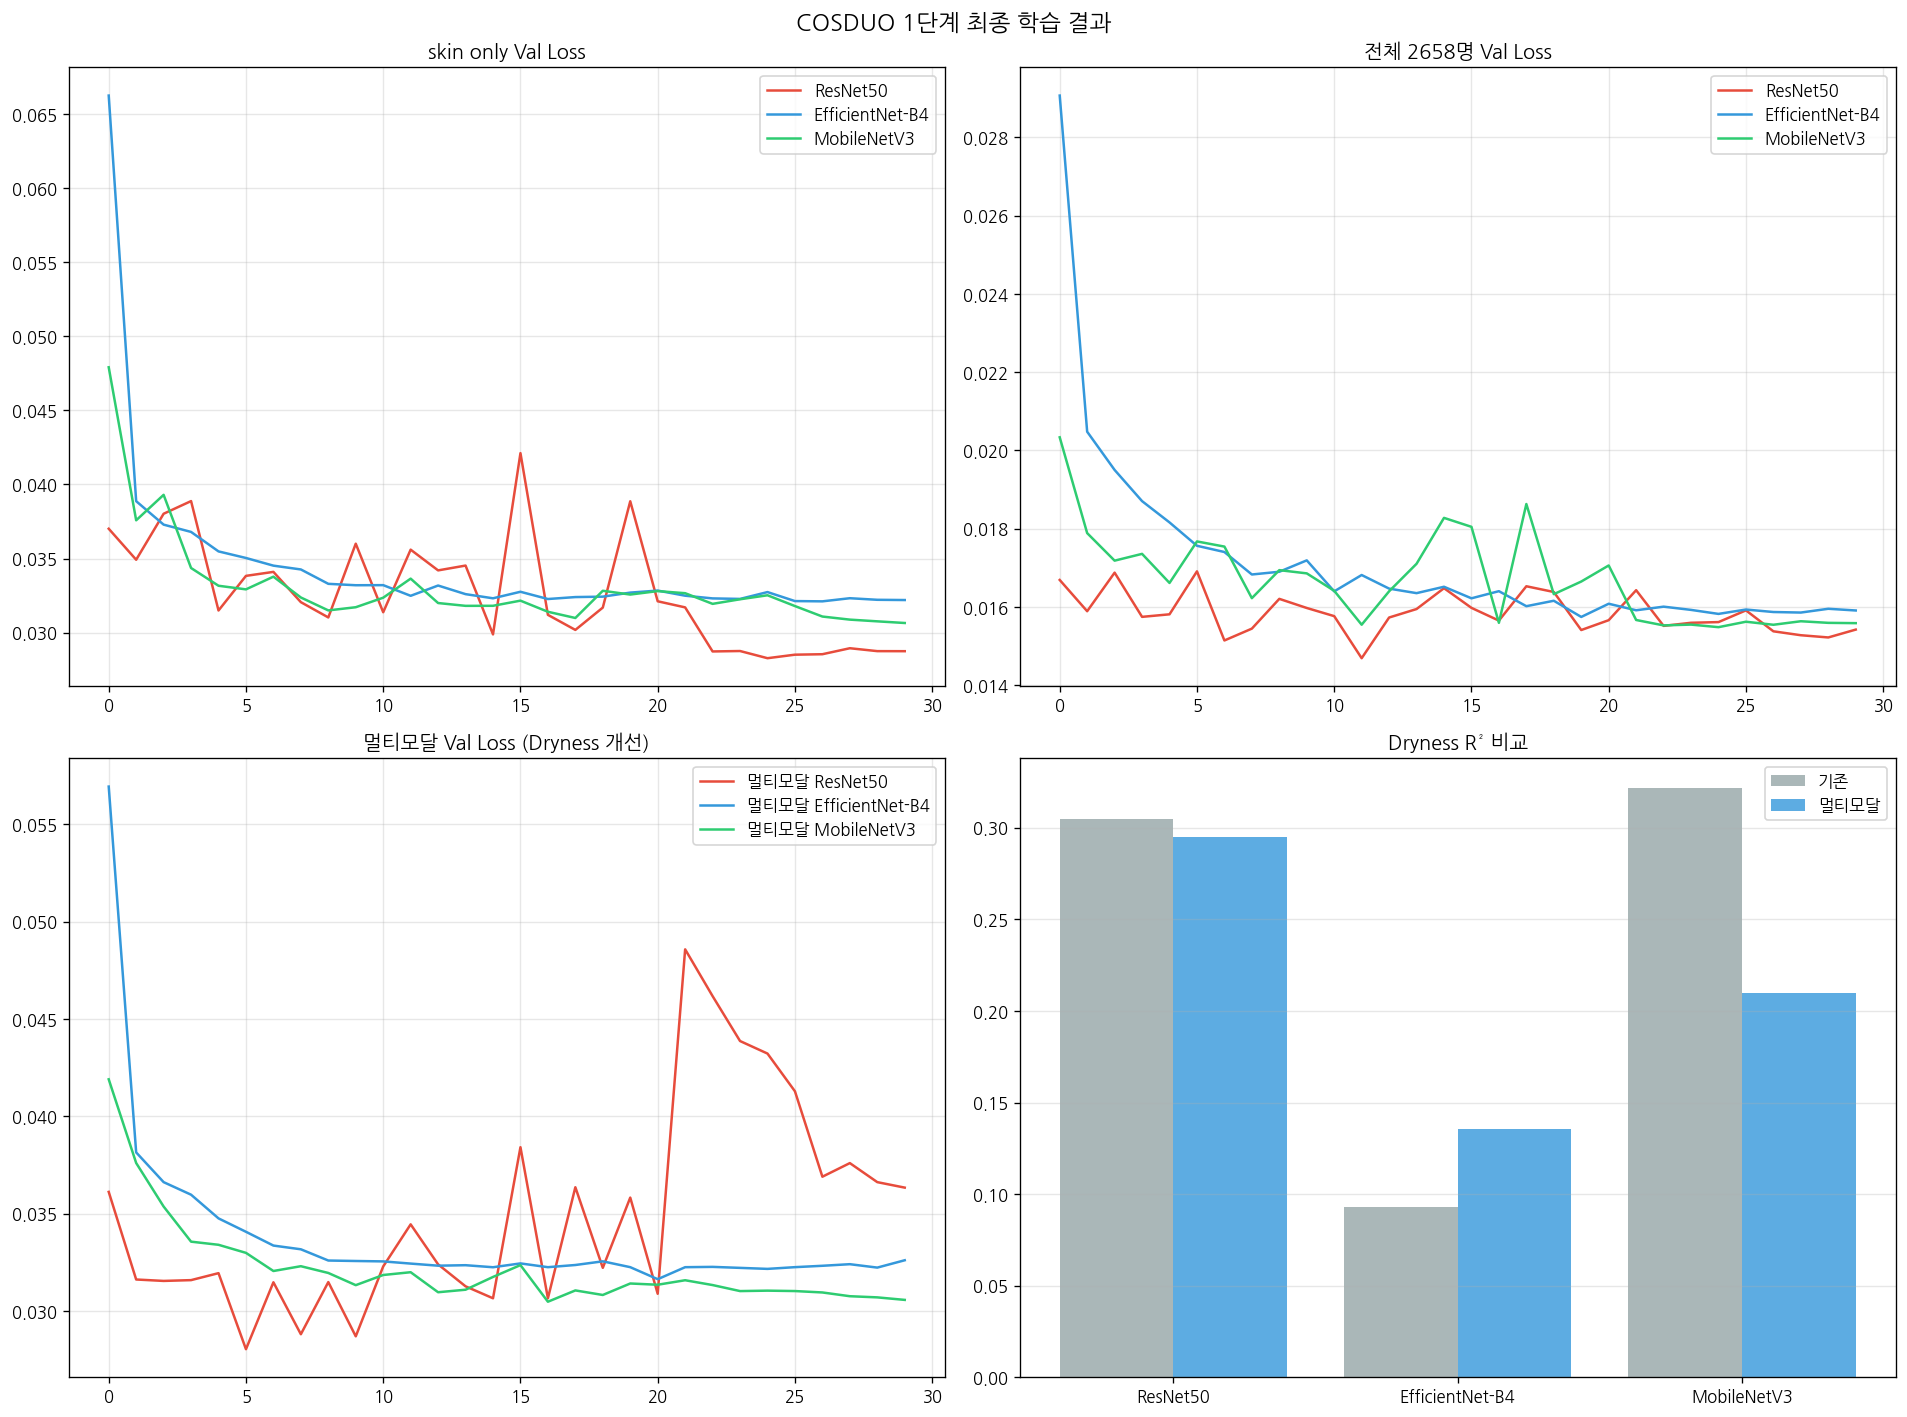

In [28]:
# 학습 곡선 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. skin only 비교
for name, hist, color in [('ResNet50', resnet_s_hist, '#E74C3C'),
                            ('EfficientNet-B4', effnet_s_hist, '#3498DB'),
                            ('MobileNetV3', mobile_s_hist, '#2ECC71')]:
    axes[0,0].plot(hist['val_loss'], color=color, label=name)
axes[0,0].set_title('skin only Val Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# 2. 전체 비교
for name, hist, color in [('ResNet50', resnet_f_hist, '#E74C3C'),
                            ('EfficientNet-B4', effnet_f_hist, '#3498DB'),
                            ('MobileNetV3', mobile_f_hist, '#2ECC71')]:
    axes[0,1].plot(hist['val_loss'], color=color, label=name)
axes[0,1].set_title('전체 2658명 Val Loss'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# 3. 멀티모달 비교
for name, hist, color in [('ResNet50', mm_resnet_hist, '#E74C3C'),
                            ('EfficientNet-B4', mm_effnet_hist, '#3498DB'),
                            ('MobileNetV3', mm_mobile_hist, '#2ECC71')]:
    axes[1,0].plot(hist['val_loss'], color=color, label=f'멀티모달 {name}')
axes[1,0].set_title('멀티모달 Val Loss (Dryness 개선)'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# 4. Dryness R² 비교
models_list = ['ResNet50', 'EfficientNet-B4', 'MobileNetV3']
orig_dry = [resnet_s_res['r2']['Dryness_Severity'], effnet_s_res['r2']['Dryness_Severity'], mobile_s_res['r2']['Dryness_Severity']]
mm_dry   = [mm_resnet_res['r2']['Dryness_Severity'], mm_effnet_res['r2']['Dryness_Severity'], mm_mobile_res['r2']['Dryness_Severity']]
x = range(len(models_list))
axes[1,1].bar([i-0.2 for i in x], orig_dry, 0.4, label='기존', color='#95A5A6', alpha=0.8)
axes[1,1].bar([i+0.2 for i in x], mm_dry,   0.4, label='멀티모달', color='#3498DB', alpha=0.8)
axes[1,1].set_title('Dryness R² 비교'); axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(models_list); axes[1,1].legend(); axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('COSDUO 1단계 최종 학습 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULT_DIR + '/final_all_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# y_labels_final.csv 저장
final_df.to_csv(LABEL_DIR + '/y_labels_final.csv', index=False)
print(f'y_labels_final.csv 저장 완료: {len(final_df)}개')
print(final_df['data_source'].value_counts())
print('\nY값 통계:')
print(final_df[Y_COLS].describe().round(2))
print('\n1단계 완료! 인계문서 수치 업데이트 후 선호에게 인계하세요.')

y_labels_final.csv 저장 완료: 2658개
data_source
aihub_disease    1800
aihub_skin        858
Name: count, dtype: int64

Y값 통계:
       Acne_Severity  Dryness_Severity  Aging_Severity  Pigmentation_Severity  \
count        2658.00           2658.00         2658.00                2658.00   
mean            6.43              6.11            2.02                   3.20   
std             3.75              0.60            0.36                   1.16   
min             0.04              3.20            0.97                   0.28   
25%             2.18              5.79            1.74                   2.24   
50%             8.16              6.11            2.04                   3.15   
75%             9.96              6.43            2.28                   4.30   
max            10.00              8.82            3.85                   6.00   

       Sensitivity_Severity  
count               2658.00  
mean                   0.64  
std                    1.93  
min                    0.00 